# Airbnb Price Prediction Data Cleaning

This notebook is used for inital viewing of data, cleaning and adjustments needed to prepare the data for modeling. EDA is also performed to gain initial insights of the data.

## Data Loading and Initial Inspection

In [1]:
# Imports
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data
RAW_DATA_PATH = Path("../data/raw/listings.csv.gz")
df = pd.read_csv(RAW_DATA_PATH)
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2708,https://www.airbnb.com/rooms/2708,20260615054117,2026-06-15,city scrape,"Run Runyon, Beaut Furn Mirror Mini-Suit w/ Fir...",Run Runyon Canyon<br /><br />Gym & Sauna <br /...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,3008,...,4.98,4.96,4.87,NaN,NaN,2,0,2,0,0.32
1,2732,https://www.airbnb.com/rooms/2732,20260615054117,2026-06-16,city scrape,Zen Life at the Beach,An oasis of tranquility awaits you.,NaN,https://a0.muscache.com/pictures/1082993/c5a99...,3041,...,4.48,4.91,4.22,228269,NaN,2,1,1,0,0.13
2,6033,https://www.airbnb.com/rooms/6033,20260615054117,2026-06-22,previous scrape,Poolside Serenity Studio,Our distinctive bachelor's studio for 1-3 gues...,NaN,https://a0.muscache.com/pictures/458111/986c76...,11619,...,4.35,4.65,4.29,NaN,NaN,7,4,3,0,0.09
3,6931,https://www.airbnb.com/rooms/6931,20260615054117,2026-06-15,city scrape,"RUN Runyon, Beau Furn Rms Terrace Hollyw Hill ...",Run Runyon Canyon & Views<br /><br />Gym & Sau...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,3008,...,4.92,4.69,4.75,NaN,NaN,2,0,2,0,0.19
4,7874,https://www.airbnb.com/rooms/7874,20260615054117,2026-06-16,city scrape,HD Wi-Fi E Bellflower Cerritos Lakewood LB LA,"Great luxury home has 2nd floor sunny, non-smo...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,21700,...,4.81,4.77,4.77,NaN,NaN,4,0,4,0,0.29


In [3]:
# Basic Overview
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


Shape: (43751, 90)

Columns:
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'p

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43751 entries, 0 to 43750
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            43751 non-null  int64  
 1   listing_url                                   43751 non-null  str    
 2   scrape_id                                     43751 non-null  int64  
 3   last_scraped                                  43751 non-null  str    
 4   source                                        43751 non-null  str    
 5   name                                          43751 non-null  str    
 6   description                                   42827 non-null  str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   43751 non-null  str    
 9   host_id                                       43751 non-null  int64  
 1

## Price Cleaning and Outlier Handling

In [5]:
# Check price column
df[["price"]].head(10)

,price
0,$67.22
1,$213.56
2,$99.63
3,$95.21
4,$113.00
5,$96.48
6,NaN
7,$198.74
8,$115.40
9,$129.91


In [6]:
# Clean price column
df["price"] = (
    df["price"]
    .astype("string")
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
    
)

print(df[["price"]].head(10))
print()
print(df["price"].describe())

    price
0   67.22
1  213.56
2   99.63
3   95.21
4  113.00
5   96.48
6     NaN
7  198.74
8  115.40
9  129.91

count    38186.000000
mean       383.395071
std        663.855892
min          3.770000
25%        115.815000
50%        223.670000
75%        405.975000
max      20583.330000
Name: price, dtype: float64


In [7]:
# Remove missing or invalid prices
starting_rows = df.shape[0]

df = df[df["price"].notna()].copy()
df = df[df["price"] > 0].copy()

print("Rows removed:", starting_rows - df.shape[0])
print("Remaining rows:", df.shape[0])

df["price"].describe()

Rows removed: 5565
Remaining rows: 38186


count    38186.000000
mean       383.395071
std        663.855892
min          3.770000
25%        115.815000
50%        223.670000
75%        405.975000
max      20583.330000
Name: price, dtype: float64

In [8]:
# Check outliers
df["price"].sort_values(ascending=False).head(20)

5986     20583.33
5098     18395.87
9813     17612.33
22867    16389.40
37077    15490.00
27158    14620.00
20304    14539.00
24258    14083.77
30122    14036.60
23162    13815.50
40259    13500.00
36934    13339.00
12979    11412.00
19127    11412.00
10898    11061.80
10573    10859.35
26955    10829.50
23867    10780.00
12211    10651.00
39008    10283.35
Name: price, dtype: float64

In [9]:
# Remove extreme outliers 
lower_bound = df["price"].quantile(0.01)
upper_bound = df["price"].quantile(0.99)

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)].copy()

df["price"].describe()

Lower bound: 34.7485
Upper bound: 2917.2395000000215


count    37422.000000
mean       337.966652
std        371.658812
min         34.750000
25%        117.260000
50%        223.670000
75%        399.670000
max       2915.000000
Name: price, dtype: float64

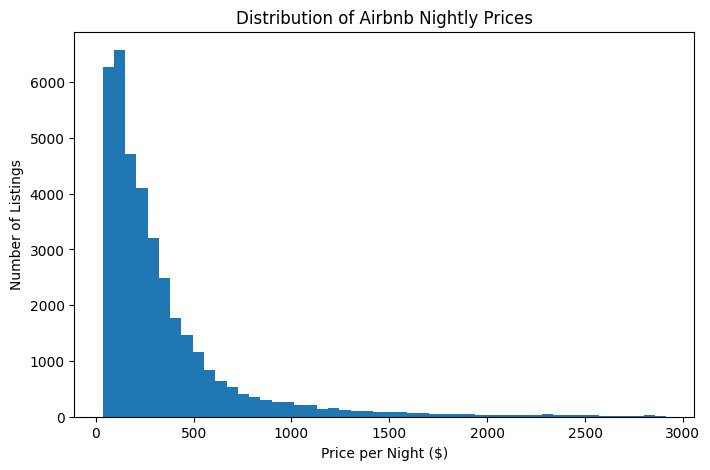

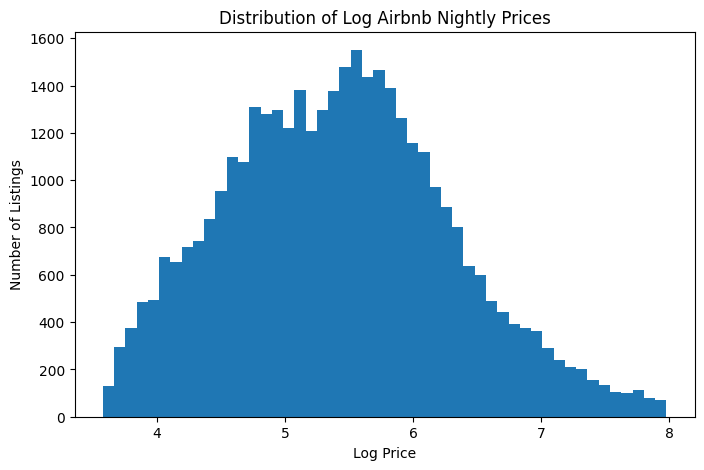

In [10]:
# Plots
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=50)
plt.title("Distribution of Airbnb Nightly Prices")
plt.xlabel("Price per Night ($)")
plt.ylabel("Number of Listings")
plt.show()

df["log_price"] = np.log1p(df["price"])
plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=50)
plt.title("Distribution of Log Airbnb Nightly Prices")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")
plt.show()

## Feature Selection and Cleaning

In [11]:
# Columns to keep
columns_to_keep = [
    "id",
    "name",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms_text",
    "bedrooms",
    "beds",
    "amenities",
    "price",
    "log_price",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value"
]

df = df[columns_to_keep].copy()
df.head()

,id,name,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,...,price,log_price,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value
0,2708,"Run Runyon, Beaut Furn Mirror Mini-Suit w/ Fir...",t,Hollywood,34.09625,-118.34605,Private room in rental unit,Private room,1,1 shared bath,...,67.22,4.222738,30.0,1125.0,301,47,4.87,4.94,4.96,4.87
1,2732,Zen Life at the Beach,f,Santa Monica,34.00440,-118.48095,Private room in rental unit,Private room,1,1 private bath,...,213.56,5.368589,1.0,27.0,350,24,4.41,4.58,4.91,4.22
2,6033,Poolside Serenity Studio,f,Woodland Hills,34.16887,-118.64478,Entire bungalow,Entire home/apt,3,1 bath,...,99.63,4.611450,30.0,1125.0,270,19,4.38,4.00,4.65,4.29
3,6931,"RUN Runyon, Beau Furn Rms Terrace Hollyw Hill ...",t,Hollywood,34.09626,-118.34372,Private room in rental unit,Private room,1,1 shared bath,...,95.21,4.566533,30.0,1125.0,259,39,4.86,4.92,4.69,4.75
4,7874,HD Wi-Fi E Bellflower Cerritos Lakewood LB LA,f,Bellflower,33.87687,-118.11444,Private room in home,Private room,2,1.5 baths,...,113.00,4.736198,1.0,730.0,103,26,4.77,4.88,4.77,4.77


In [12]:
# Cleaning columns

# Superhost
df["host_is_superhost"] = df["host_is_superhost"].map({"t" : 1, "f" : 0})

# Bathrooms
def parse_bathrooms(text):
    if pd.isna(text):
        return np.nan
    text = str(text).lower()

    if "half bath" in text or "half-bath" in text:
        return 0.5

    for word in text.split():
        try:
            return float(word)
        except ValueError:
            continue

    return np.nan

df["bathrooms"] = df["bathrooms_text"].apply(parse_bathrooms)
df[["bathrooms_text", "bathrooms"]].head(10)

,bathrooms_text,bathrooms
0,1 shared bath,1.0
1,1 private bath,1.0
2,1 bath,1.0
3,1 shared bath,1.0
4,1.5 baths,1.5
5,1 private bath,1.0
7,1 shared bath,1.0
8,1 bath,1.0
9,1 bath,1.0
10,1 bath,1.0


In [13]:
# Amenities
import ast

def count_amenities(value):
    if pd.isna(value):
        return 0
    try:
        amenities_list = ast.literal_eval(value)
        return len(amenities_list)
    except:
        return 0

df["amenities_count"] = df["amenities"].apply(count_amenities)
df[["amenities", "amenities_count"]].head()

,amenities,amenities_count
0,"[""Shared sauna"", ""Laundromat nearby"", ""Lock on...",77
1,"[""Smoke alarm"", ""Wifi"", ""Microwave"", ""Host gre...",19
2,"[""Washer"", ""Self check-in"", ""Private entrance""...",32
3,"[""Coffee maker"", ""Laundromat nearby"", ""Lock on...",72
4,"[""TV"", ""Air conditioning"", ""Lock on bedroom do...",22


In [14]:
# Cap extreme minimum and maximum-night requirements
MINIMUM_NIGHTS_CAP = 365
MAXIMUM_NIGHTS_CAP = 1125

minimum_nights_capped = (df["minimum_nights"] > MINIMUM_NIGHTS_CAP).sum()
maximum_nights_capped = (df["maximum_nights"] > MAXIMUM_NIGHTS_CAP).sum()

df["minimum_nights"] = df["minimum_nights"].clip(
    lower=1,
    upper=MINIMUM_NIGHTS_CAP,
)
df["maximum_nights"] = df["maximum_nights"].clip(
    lower=1,
    upper=MAXIMUM_NIGHTS_CAP,
)

print("Minimum-night values capped:", minimum_nights_capped)
print("Maximum-night values capped:", maximum_nights_capped)
print(df[["minimum_nights", "maximum_nights"]].describe())


Minimum-night values capped: 0
Maximum-night values capped: 4
       minimum_nights  maximum_nights
count     37413.00000    37413.000000
mean         15.17240      544.178280
std          15.83718      411.771847
min           1.00000        1.000000
25%           1.00000      365.000000
50%           4.00000      365.000000
75%          30.00000     1125.000000
max         365.00000     1125.000000


In [15]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

review_scores_value          0.248036
review_scores_location       0.248009
review_scores_cleanliness    0.247956
review_scores_rating         0.247876
bedrooms                     0.209289
beds                         0.044386
bathrooms                    0.004276
bathrooms_text               0.004276
host_is_superhost            0.003901
minimum_nights               0.000241
maximum_nights               0.000241
dtype: float64

## EDA

In [16]:
room_price = (
    df.groupby("room_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

room_price

room_type
Hotel room         485.707374
Entire home/apt    402.221062
Private room       132.833477
Shared room        122.370207
Name: price, dtype: float64

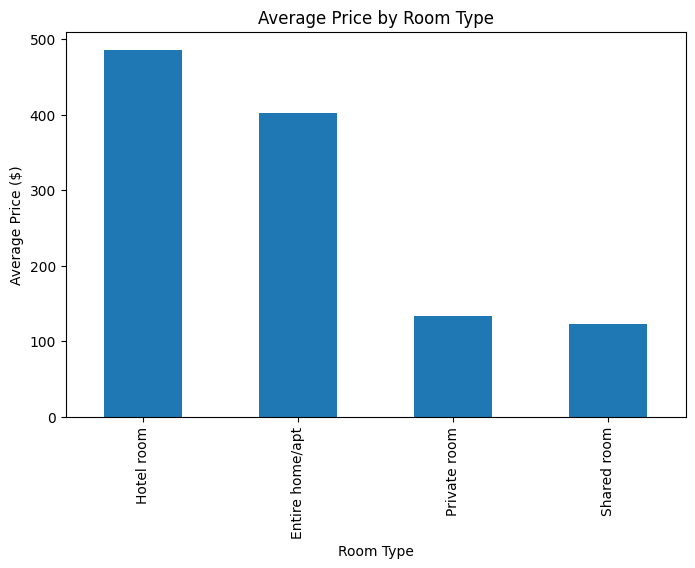

In [17]:
plt.figure(figsize=(8, 5))
room_price.plot(kind="bar")
plt.xlabel("Room Type")
plt.ylabel("Average Price ($)")
plt.title("Average Price by Room Type")
plt.show()

**Room type:** Hotel rooms and entire homes/apartments have the highest average nightly prices, at about $486 and $402. Private and shared rooms are much cheaper, averaging roughly $133 and $122 per night.

In [18]:
neighborhood_price = (
    df.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

neighborhood_price

neighbourhood_cleansed
Beverly Crest                            1194.744625
Unincorporated Catalina Island           1148.625000
Malibu                                   1039.390298
Hollywood Hills West                      987.646697
Bel-Air                                   985.002037
Avalon                                    914.965290
Unincorporated Santa Monica Mountains     833.340807
Palos Verdes Estates                      795.443889
Manhattan Beach                           735.553049
Cheviot Hills                             669.003846
Pacific Palisades                         625.097204
Veterans Administration                   624.220000
Hidden Hills                              582.053333
Fairfax                                   567.781620
Tarzana                                   555.645543
Name: price, dtype: float64

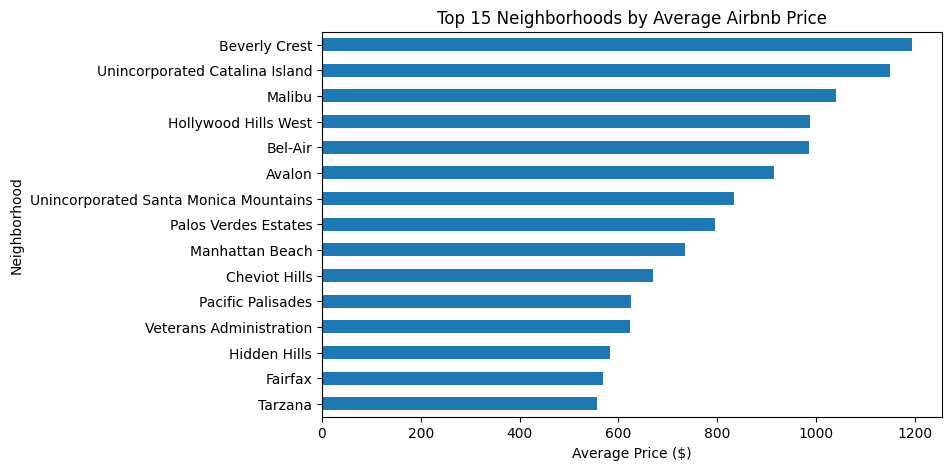

In [19]:
plt.figure(figsize=(8, 5))
neighborhood_price.sort_values().plot(kind="barh")
plt.xlabel("Average Price ($)")
plt.ylabel("Neighborhood")
plt.title("Top 15 Neighborhoods by Average Airbnb Price")
plt.show()

**Neighborhood:** Average nightly price varies substantially by location. Beverly Crest and Unincorporated Catalina Island are the most expensive areas shown, both averaging over $1,100 per night, followed by Malibu, Hollywood Hills West, and Bel-Air.

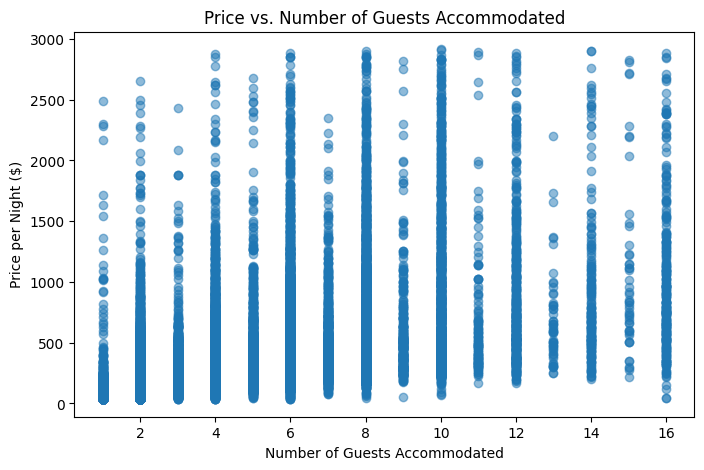

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df["accommodates"], df["price"], alpha=0.5)
plt.xlabel("Number of Guests Accommodated")
plt.ylabel("Price per Night ($)")
plt.title("Price vs. Number of Guests Accommodated")
plt.show()

**Guest capacity:** Listings that accommodate more guests generally tend to have higher nightly prices, but the wide vertical spread at every capacity shows that guest count alone does not explain price. Other features such as room type, location, and amenities are also important.

## Correlation Analysis

In [21]:
numeric_cols = [
    "price",
    "log_price",
    "latitude",
    "longitude",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_value",
    "review_scores_location",
    "host_is_superhost",
    "amenities_count"
]

corr_with_price = (
    df[numeric_cols].corr(numeric_only=True)["price"]
    .sort_values(ascending=False)

)

corr_with_price

price                        1.000000
log_price                    0.849831
bathrooms                    0.616290
accommodates                 0.591803
bedrooms                     0.578508
beds                         0.520317
amenities_count              0.253335
review_scores_location       0.111126
review_scores_cleanliness    0.084024
review_scores_rating         0.078812
host_is_superhost            0.062368
review_scores_value          0.045345
maximum_nights               0.009203
availability_365             0.007691
number_of_reviews           -0.038078
latitude                    -0.074709
longitude                   -0.201476
minimum_nights              -0.227650
Name: price, dtype: float64

## Final Dataset and Export

In [24]:
# Final cleaned dataset
model_columns = [
    "id",
    "price",
    "log_price",
    "host_is_superhost",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_365",
    "number_of_reviews",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "amenities_count",
]

clean_df = df[model_columns].copy()

target_column = "log_price"
excluded_from_features = ["id", "price", "log_price"]

X = clean_df.drop(columns=excluded_from_features)
y = clean_df[target_column].copy()

print("clean_df shape:", clean_df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target:", y.name)

X.head()


clean_df shape: (37422, 22)
X shape: (37422, 19)
y shape: (37422,)
Target: log_price


,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,amenities_count
0,1.0,Hollywood,34.09625,-118.34605,Private room in rental unit,Private room,1,1.0,NaN,1.0,30.0,1125.0,301,47,4.87,4.94,4.96,4.87,77
1,0.0,Santa Monica,34.00440,-118.48095,Private room in rental unit,Private room,1,1.0,NaN,1.0,1.0,27.0,350,24,4.41,4.58,4.91,4.22,19
2,0.0,Woodland Hills,34.16887,-118.64478,Entire bungalow,Entire home/apt,3,1.0,1.0,NaN,30.0,1125.0,270,19,4.38,4.00,4.65,4.29,32
3,1.0,Hollywood,34.09626,-118.34372,Private room in rental unit,Private room,1,1.0,NaN,1.0,30.0,1125.0,259,39,4.86,4.92,4.69,4.75,72
4,0.0,Bellflower,33.87687,-118.11444,Private room in home,Private room,2,1.5,NaN,1.0,1.0,730.0,103,26,4.77,4.88,4.77,4.77,22


In [ ]:
# Save cleaned data
PROCESSED_DATA_PATH = Path("../data/processed/clean_listings.csv")
clean_df.to_csv(PROCESSED_DATA_PATH, index=False)

print("Saved cleaned data to:", PROCESSED_DATA_PATH)
print("Final shape:", clean_df.shape)

Saved cleaned data to: ../data/processed/clean_listings.csv
Final shape: (37422, 22)


In [26]:
# Verify saved data
saved_df = pd.read_csv(PROCESSED_DATA_PATH)

print(saved_df.shape)
saved_df.head()

(37422, 22)


,id,price,log_price,host_is_superhost,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,...,beds,minimum_nights,maximum_nights,availability_365,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,amenities_count
0,2708,67.22,4.222738,1.0,Hollywood,34.09625,-118.34605,Private room in rental unit,Private room,1,...,1.0,30.0,1125.0,301,47,4.87,4.94,4.96,4.87,77
1,2732,213.56,5.368589,0.0,Santa Monica,34.00440,-118.48095,Private room in rental unit,Private room,1,...,1.0,1.0,27.0,350,24,4.41,4.58,4.91,4.22,19
2,6033,99.63,4.611450,0.0,Woodland Hills,34.16887,-118.64478,Entire bungalow,Entire home/apt,3,...,NaN,30.0,1125.0,270,19,4.38,4.00,4.65,4.29,32
3,6931,95.21,4.566533,1.0,Hollywood,34.09626,-118.34372,Private room in rental unit,Private room,1,...,1.0,30.0,1125.0,259,39,4.86,4.92,4.69,4.75,72
4,7874,113.00,4.736198,0.0,Bellflower,33.87687,-118.11444,Private room in home,Private room,2,...,1.0,1.0,730.0,103,26,4.77,4.88,4.77,4.77,22
